# Методичка

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import make_classification
X, Y = make_classification(n_samples=1000, n_classes=2, n_features=5, n_redundant=0, random_state=1)

In [ ]:
X.shape, Y.shape

((1000, 5), (1000,))

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [ ]:
X_train.shape, Y_train.shape

((800, 5), (800,))

In [ ]:
X_test.shape, Y_test.shape

((200, 5), (200,))

In [ ]:
import pandas as pd

from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import SGDClassifier

In [ ]:
names = ["Nearest_Neighbors", "Linear_SVM", "Polynomial_SVM", "RBF_SVM", "Gaussian_Process",
         "Gradient_Boosting", "Decision_Tree", "Extra_Trees", "Random_Forest", "Neural_Net", "AdaBoost",
         "Naive_Bayes", "QDA", "SGD"]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(kernel="poly", degree=3, C=0.025),
    SVC(kernel="rbf", C=1, gamma=2),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    GradientBoostingClassifier(n_estimators=100, learning_rate=1.0),
    DecisionTreeClassifier(max_depth=5),
    ExtraTreesClassifier(n_estimators=10, min_samples_split=2),
    RandomForestClassifier(max_depth=5, n_estimators=100),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(n_estimators=100),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    SGDClassifier(loss="hinge", penalty="l2")]

In [ ]:
scores = []
for name, clf in zip(names, classifiers):
    clf.fit(X_train, Y_train)
    score = clf.score(X_test, Y_test)
    scores.append(score)

In [ ]:
df = pd.DataFrame()
df['name'] = names
df['score'] = scores
df.sort_values(by=["score"], ascending=False, inplace=True)
df

,name,score
9,Neural_Net,0.865
6,Decision_Tree,0.865
4,Gaussian_Process,0.860
8,Random_Forest,0.855
10,AdaBoost,0.855
5,Gradient_Boosting,0.855
12,QDA,0.855
11,Naive_Bayes,0.850
1,Linear_SVM,0.850
0,Nearest_Neighbors,0.835


In [ ]:
cm = sns.light_palette("lavender", as_cmap=True)
s = df.style.background_gradient(cmap=cm)
s

,name,score
9,Neural_Net,0.865000
6,Decision_Tree,0.865000
4,Gaussian_Process,0.860000
8,Random_Forest,0.855000
10,AdaBoost,0.855000
5,Gradient_Boosting,0.855000
12,QDA,0.855000
11,Naive_Bayes,0.850000
1,Linear_SVM,0.850000
0,Nearest_Neighbors,0.835000


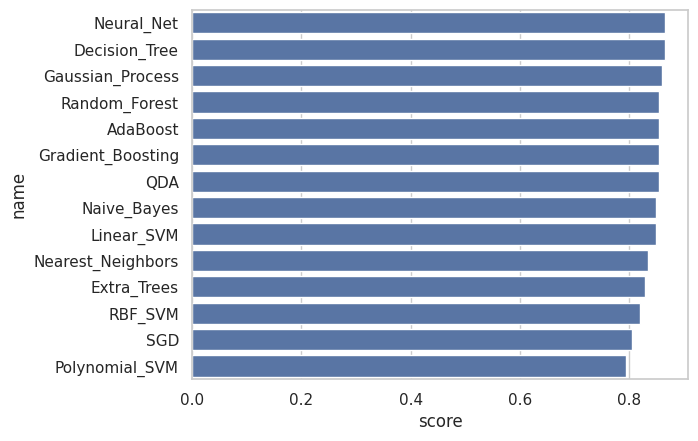

In [ ]:
sns.set(style="whitegrid")
ax = sns.barplot(y="name", x="score", data=df)

## Поиск по сетке

In [ ]:
df = pd.read_csv("Advertising.csv")

In [ ]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [ ]:
## Создаём X и y
X = df.drop('sales',axis=1)
y = df['sales']

# Разбиение на обучающий и тестовый наборы - TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Масштабирование данных (SCALE)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import ElasticNet

In [ ]:
base_elastic_model = ElasticNet()

In [ ]:
param_grid = {'alpha':[0.1,1,5,10,50,100],
              'l1_ratio':[.1, .5, .7, .9, .95, .99, 1]}

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# число verbose выбирайте сами
grid_model = GridSearchCV(estimator=base_elastic_model,
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error',
                          cv=5,
                          verbose=3)

In [ ]:
grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 42 candidates, totalling 210 fits
[CV 1/5] END ..........alpha=0.1, l1_ratio=0.1;, score=-3.453 total time=   0.0s
[CV 2/5] END ..........alpha=0.1, l1_ratio=0.1;, score=-1.405 total time=   0.0s
[CV 3/5] END ..........alpha=0.1, l1_ratio=0.1;, score=-5.789 total time=   0.0s
[CV 4/5] END ..........alpha=0.1, l1_ratio=0.1;, score=-2.187 total time=   0.0s
[CV 5/5] END ..........alpha=0.1, l1_ratio=0.1;, score=-4.646 total time=   0.0s
[CV 1/5] END ..........alpha=0.1, l1_ratio=0.5;, score=-3.325 total time=   0.0s
[CV 2/5] END ..........alpha=0.1, l1_ratio=0.5;, score=-1.428 total time=   0.0s
[CV 3/5] END ..........alpha=0.1, l1_ratio=0.5;, score=-5.596 total time=   0.0s
[CV 4/5] END ..........alpha=0.1, l1_ratio=0.5;, score=-2.163 total time=   0.0s
[CV 5/5] END ..........alpha=0.1, l1_ratio=0.5;, score=-4.452 total time=   0.0s
[CV 1/5] END ..........alpha=0.1, l1_ratio=0.7;, score=-3.270 total time=   0.0s
[CV 2/5] END ..........alpha=0.1, l1_ratio=0.7;

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.1, 1, 5, 10, 50, 100],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]},
             scoring='neg_mean_squared_error', verbose=3)

In [ ]:
grid_model.best_estimator_

ElasticNet(alpha=0.1, l1_ratio=1)

In [ ]:
y_pred = grid_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
mean_squared_error(y_test,y_pred)

2.387342642087474

#Дополнительные задания

## 1. При выборе модели мы обычно выбираем ту, которая дает наибольшее значение какой-то метрики. Но это означает, что эта оценка метрики уже становится завышенной. Поэтому для объективной оценки качества модели ее опять следует оценить на новом наборе данных. Поэтому для выбора модели нужно разделить выборку на три части - обучающую, валидационную и тестовую. Повторите первую часть работы, но с таким разбиением и получите несмещенную оценку качества наилучшей модели

In [ ]:
X, Y = make_classification(n_samples=1000, n_classes=2, n_features=5, n_redundant=0, random_state=1)

In [ ]:
X_train, x, Y_train, y = train_test_split(X, Y, test_size=0.3, random_state=42)
X_valid, X_test, Y_valid, Y_test = train_test_split(x, y, test_size=0.5, random_state=42)

In [ ]:
X_train.shape, X_valid.shape, X_test.shape

((700, 5), (150, 5), (150, 5))

In [ ]:
names = ["Nearest_Neighbors", "Linear_SVM", "Polynomial_SVM", "RBF_SVM", "Gaussian_Process",
         "Gradient_Boosting", "Decision_Tree", "Extra_Trees", "Random_Forest", "Neural_Net", "AdaBoost",
         "Naive_Bayes", "QDA", "SGD"]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(kernel="poly", degree=3, C=0.025),
    SVC(kernel="rbf", C=1, gamma=2),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    GradientBoostingClassifier(n_estimators=100, learning_rate=1.0),
    DecisionTreeClassifier(max_depth=5),
    ExtraTreesClassifier(n_estimators=10, min_samples_split=2),
    RandomForestClassifier(max_depth=5, n_estimators=100),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(n_estimators=100),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    SGDClassifier(loss="hinge", penalty="l2")]

In [ ]:
val_scores = []
for name, clf in zip(names, classifiers):
    clf.fit(X_train, Y_train)
    score = clf.score(X_valid, Y_valid)
    val_scores.append(score)

In [ ]:
df = pd.DataFrame()
df['name'] = names
df['val_score'] = val_scores
df.sort_values(by=["val_score"], ascending=False, inplace=True)
df

,name,val_score
4,Gaussian_Process,0.866667
9,Neural_Net,0.860000
10,AdaBoost,0.853333
11,Naive_Bayes,0.853333
3,RBF_SVM,0.846667
1,Linear_SVM,0.846667
8,Random_Forest,0.846667
7,Extra_Trees,0.846667
12,QDA,0.846667
6,Decision_Tree,0.846667


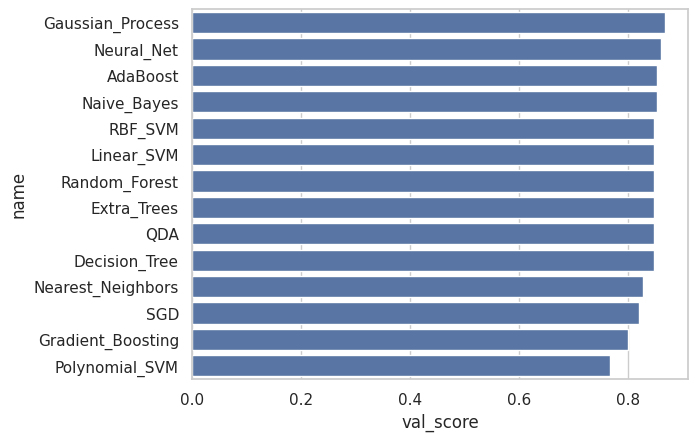

In [ ]:
sns.set(style="whitegrid")
ax = sns.barplot(y="name", x="val_score", data=df)

In [ ]:
best_classifier_index = np.argmax(val_scores)
best_classifier_name = names[best_classifier_index]
best_classifier = classifiers[best_classifier_index]

In [ ]:
best_classifier_name

'Gaussian_Process'

In [ ]:
best_classifier_score = best_classifier.score(X_test, Y_test)
best_classifier_score

0.8733333333333333

## 2. Оптимизируйте гиперпараметры той же модели, но другим методом - случайным поиском. Сравните полученные результаты.


In [ ]:
df = pd.read_csv("Advertising.csv")

In [ ]:
## Создаём X и y
X = df.drop('sales',axis=1)
y = df['sales']

# Разбиение на обучающий и тестовый наборы - TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Масштабирование данных (SCALE)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
param_grid = {'alpha':[0.1,1,5,10,50,100],
              'l1_ratio':[.1, .5, .7, .9, .95, .99, 1]}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
random_search_model = RandomizedSearchCV(estimator=base_elastic_model,
                                   param_distributions=param_grid,
                                   n_iter=20,
                                   scoring='neg_mean_squared_error',
                                   cv=5,
                                   verbose=3,
                                   random_state=42)

In [ ]:
random_search_model.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END .........alpha=10, l1_ratio=0.95;, score=-31.130 total time=   0.0s
[CV 2/5] END .........alpha=10, l1_ratio=0.95;, score=-22.549 total time=   0.0s
[CV 3/5] END .........alpha=10, l1_ratio=0.95;, score=-31.155 total time=   0.0s
[CV 4/5] END .........alpha=10, l1_ratio=0.95;, score=-27.963 total time=   0.0s
[CV 5/5] END .........alpha=10, l1_ratio=0.95;, score=-21.698 total time=   0.0s
[CV 1/5] END ..............alpha=1, l1_ratio=1;, score=-6.469 total time=   0.0s
[CV 2/5] END ..............alpha=1, l1_ratio=1;, score=-2.391 total time=   0.0s
[CV 3/5] END ..............alpha=1, l1_ratio=1;, score=-8.410 total time=   0.0s
[CV 4/5] END ..............alpha=1, l1_ratio=1;, score=-3.894 total time=   0.0s
[CV 5/5] END ..............alpha=1, l1_ratio=1;, score=-5.106 total time=   0.0s
[CV 1/5] END ............alpha=1, l1_ratio=0.5;, score=-8.707 total time=   0.0s
[CV 2/5] END ............alpha=1, l1_ratio=0.5;

RandomizedSearchCV(cv=5, estimator=ElasticNet(), n_iter=20,
                   param_distributions={'alpha': [0.1, 1, 5, 10, 50, 100],
                                        'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95,
                                                     0.99, 1]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=3)

In [ ]:
random_search_model.best_estimator_

ElasticNet(alpha=0.1, l1_ratio=1)

In [ ]:
y_pred = random_search_model.predict(X_test)

In [ ]:
mean_squared_error(y_test,y_pred)

2.387342642087474

## 3.Во второй задаче найдите наиболее эффективный класс моделей, а затем оптимизируйте гиперпараметры у этой модели. Сравните, насколько лучше получилась модель.

In [ ]:
df = pd.read_csv("Advertising.csv")

In [ ]:
## Создаём X и y
X = df.drop('sales',axis=1)
y = df['sales']

# Разбиение на обучающий и тестовый наборы - TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Масштабирование данных (SCALE)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

In [ ]:
names = [
    "LinearRegression",
    "Ridge",
    "Lasso",
    "ElasticNet",
    "DecisionTreeRegressor",
    "RandomForestRegressor",
    "GradientBoostingRegressor",
    "MLPRegressor",
    "SVR"
]

regression_models = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    ElasticNet(),
    DecisionTreeRegressor(),
    RandomForestRegressor(),
    GradientBoostingRegressor(),
    MLPRegressor(),
    SVR()]

In [ ]:
scores = []
for name, reg in zip(names, regression_models):
    reg.fit(X_train, y_train)
    score = reg.score(X_test, y_test)
    scores.append(score)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
df = pd.DataFrame()
df['name'] = names
df['score'] = scores
df.sort_values(by=["score"], ascending=False, inplace=True)
df

,name,score
6,GradientBoostingRegressor,0.981572
5,RandomForestRegressor,0.979096
4,DecisionTreeRegressor,0.953198
0,LinearRegression,0.918578
1,Ridge,0.917859
8,SVR,0.902097
2,Lasso,0.826626
3,ElasticNet,0.733062
7,MLPRegressor,-1.003092


In [ ]:
model = GradientBoostingRegressor()

In [ ]:
params_grid = {
    'n_estimators': [100, 200, 400, 800], #количество базовых моделей (деревьев) в ансамбле
    'learning_rate': [0.2, 0.3], # скорость обучения, коэффициент, с которым каждое дерево вносит свой вклад в итоговый прогноз.
    'max_depth': [i for i in range(2, 4)], # максимальная глубина каждого дерева.
    'min_samples_split': [i for i in range(2, 6)], # минимальное количество выборок, необходимых для разделения внутреннего узла.
    'min_samples_leaf': [i for i in range(3, 5)], #  минимальное количество выборок, необходимых для формирования листа дерева.
}

In [ ]:
grid_model = GridSearchCV(estimator=model,
                          param_grid=params_grid,
                          scoring='neg_mean_squared_error',
                          cv=5,
                          verbose=3)

In [ ]:
grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
[CV 1/5] END learning_rate=0.2, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=100;, score=-0.694 total time=   0.0s
[CV 2/5] END learning_rate=0.2, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=100;, score=-0.380 total time=   0.0s
[CV 3/5] END learning_rate=0.2, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=100;, score=-1.743 total time=   0.0s
[CV 4/5] END learning_rate=0.2, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=100;, score=-0.929 total time=   0.0s
[CV 5/5] END learning_rate=0.2, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=100;, score=-1.238 total time=   0.0s
[CV 1/5] END learning_rate=0.2, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=200;, score=-0.690 total time=   0.1s
[CV 2/5] END learning_rate=0.2, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=200;, score=-0.3

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(),
             param_grid={'learning_rate': [0.2, 0.3], 'max_depth': [2, 3],
                         'min_samples_leaf': [3, 4],
                         'min_samples_split': [2, 3, 4, 5],
                         'n_estimators': [100, 200, 400, 800]},
             scoring='neg_mean_squared_error', verbose=3)

In [ ]:
grid_model.best_estimator_

GradientBoostingRegressor(learning_rate=0.2, min_samples_leaf=3,
                          n_estimators=200)

In [ ]:
best_model = GradientBoostingRegressor(learning_rate=0.2, max_depth=3,
                          min_samples_leaf=3, n_estimators=200).fit(X_train,y_train)

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
mean_squared_error(y_test,y_pred)

0.5398346555031311